In [4]:
suppressPackageStartupMessages({
    library(DESeq2)
    library(ggplot2)
    library(rtracklayer)
    library(pheatmap)
    library(RColorBrewer)
    library(ggrepel)
    library(reshape2)
    library(dplyr)
    library(data.table)
    library(tidyr)
    library(ggpubr)
    library(purrr)
    library(patchwork)
    library(pheatmap)
})

In [5]:
countData <- as.matrix(read.csv('gene_count_matrix_epiblast.csv', row.names = 'gene_id'))
rownames(countData) = rownames(countData) %>% strsplit('[|]') %>% map(2) # change rownames

colData <- read.csv('phenodata_epi2.csv', row.names = 1)
colData$genotype = gsub("-/-", "null", colData$genotype)
colData$group = paste0(colData$genotype, '_',colData$stage)


In [5]:
#E5.5, E6.5, E7.5
##Remove ex5.5 results
#select E7.5 data
colE567 <- colData[colData$stage!="ex5.5",]
#remove E7.5_WT_3
colE567 <- colE567[!rownames(colE567) %in% c("E5.5_Stat3null_1", "E6.5_Stat3null_1", "E6.5_Stat3null_2", "E6.5_WT_1", "E6.5_WT_2", "E6.5_WT_3", "E6.5_WT_4", "E7.5_WT_3"), ]
colE567$genotype <- factor(colE567$genotype, levels = c("WT", "Stat3null"))
countDataE567 <- countData[, rownames(colE567)]
rownames(countDataE567) = make.names(rownames(countDataE567), unique=TRUE)
head(countDataE567)

,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_3,E6.5_Stat3null_4,E6.5_Stat3null_5,E6.5_Stat3null_6,E6.5_Stat3null_7,⋯,E7.5_Stat3null_2,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
Xkr4,5,11,6,4,48,0,96,94,76,142,⋯,215,235,232,134,170,315,138,178,166,180
Gm18956,4,0,0,0,0,0,0,0,0,0,⋯,3,2,3,0,0,0,4,5,0,0
Gm37686,0,0,0,0,0,0,4,0,0,0,⋯,18,0,27,4,3,10,11,0,0,3
Gm1992,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Gm37329,5,11,20,0,0,0,0,4,13,22,⋯,48,10,9,13,9,0,23,8,18,0
Gm38148,19,23,11,0,7,0,33,57,43,53,⋯,80,6,50,47,25,43,8,36,63,91


In [6]:
##Check all sample IDs in colData are also in CountData and match their orders (phenodata.csvとサンプルが噛み合うか確認)
all(rownames(colE567) %in% colnames(countDataE567))
countDataE567 <- countDataE567[, rownames(colE567)]
all(rownames(colE567) == colnames(countDataE567))

[1] TRUE

[1] TRUE

In [7]:
##Create a DESeqDataSet from count matrix and labels (DESeqDataSetを作成）

ddsFullE567 <-DESeqDataSetFromMatrix(countData = countDataE567, colData = colE567, design = ~ stage + genotype + genotype:stage)  # group
ddsFullE567 <- ddsFullE567[rowSums(counts(ddsFullE567)) > 10, ]
ddsFullE567$genotype <- factor(ddsFullE567$genotype, levels = c("WT","Stat3null"))
ddsFullE567$stage <- factor(ddsFullE567$stage, levels = c("E5.5","E6.5", "E7.5")) # does DESeq just not work with 3 values?


# Normalisation
ddsFullE567 <- estimateSizeFactors(ddsFullE567)
normalized_counts <- counts(ddsFullE567, normalized=TRUE)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


In [9]:
#normalization
rld_E567 <- rlog(ddsFullE567, blind = TRUE)
rld_E567$genotype <- factor(rld_E567$genotype, levels = c("WT", "Stat3null"))

In [94]:
counts = assay(rld_E567)

In [17]:
head(colData)

,stage,genotype,cluster,group
,<chr>,<fct>,<int>,<chr>
E5.5_Stat3null_1,E5.5,Stat3null,1,Stat3null_E5.5
E5.5_Stat3null_2,E5.5,Stat3null,1,Stat3null_E5.5
E5.5_Stat3null_3,E5.5,Stat3null,1,Stat3null_E5.5
E5.5_Stat3null_4,E5.5,Stat3null,1,Stat3null_E5.5
E5.5_WT_1,E5.5,WT,1,WT_E5.5
E5.5_WT_2,E5.5,WT,1,WT_E5.5


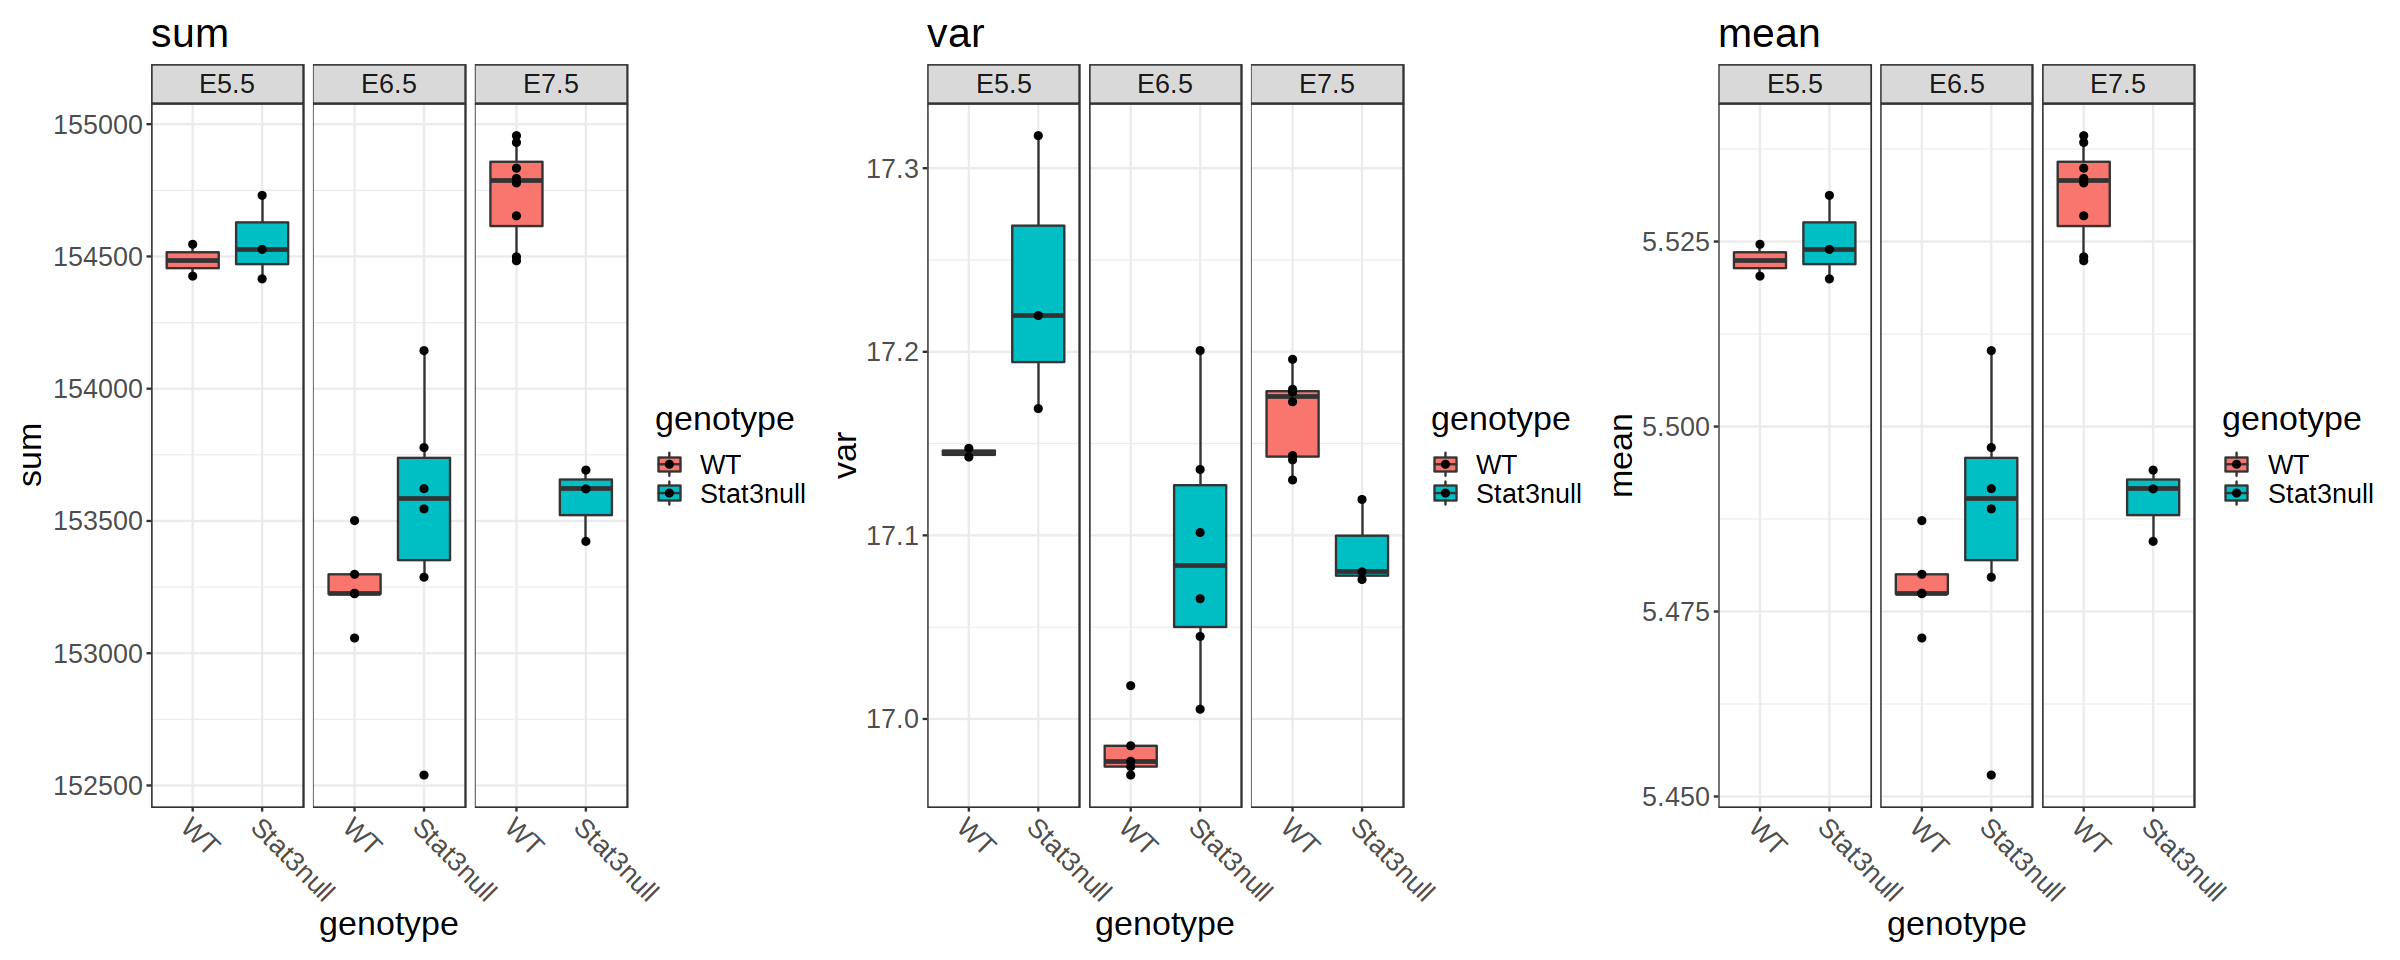

In [26]:
# sample statistics
sample = data.table(sample=colnames(counts), 
                   sum = colSums(counts), 
                   mean = colMeans(counts), 
                   var = colVars(counts))
meta_sample = merge(colData, sample, by.x=0, by.y='sample')

plot_stat = function(x){
    ggplot(meta_sample, aes_string('genotype', x, fill='genotype')) + 
        geom_boxplot(outlier.shape = NA) + 
        geom_point() + 
        viridis::scale_color_viridis() + 
        facet_wrap(~stage) + 
        ggtitle(x) +
        theme_bw() + 
        theme(text=element_text(size=20), 
                   axis.text.x=element_text(angle=-45, hjust=0, vjust=1))
    }
options(repr.plot.width=20, repr.plot.height=8)
plot_stat('sum') + plot_stat('var') + plot_stat('mean')
options(repr.plot.width=10, repr.plot.height=8)

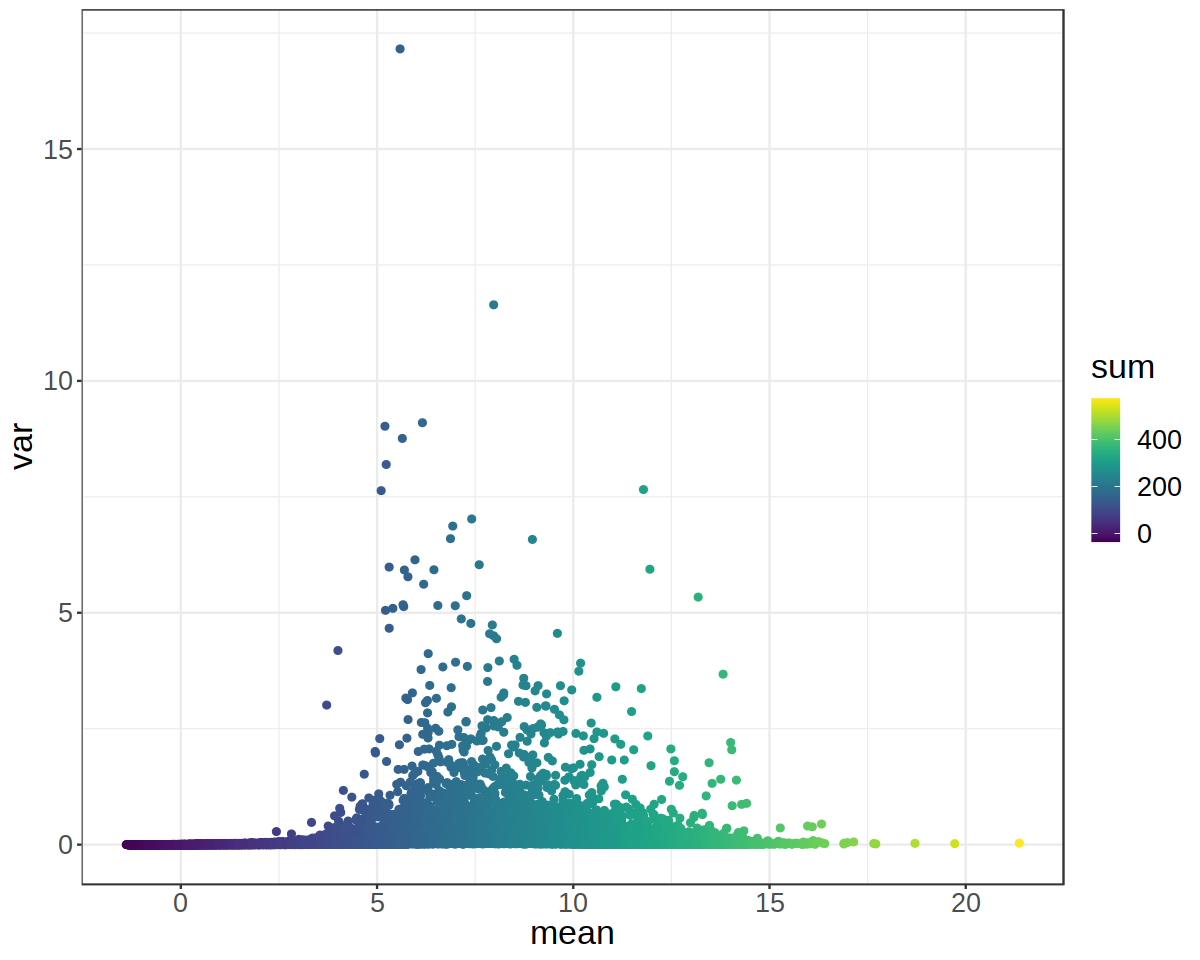

In [21]:
# Gene statistics
genes = data.table(gene=rownames(counts), 
                   sum = rowSums(counts), 
                   mean = rowMeans(counts), 
                   var = rowVars(counts))

ggplot(genes, aes(mean, var, col=sum)) + 
    geom_point() + 
    viridis::scale_color_viridis() + 
    theme_bw() + theme(text=element_text(size=20))

In [30]:
head(genes)

gene,sum,mean,var
<chr>,<dbl>,<dbl>,<dbl>
Xkr4,178.70145,6.618572,0.2728417369
Gm18956,-9.37081,-0.347067,0.0002876182
Gm37686,60.72101,2.248926,0.0042935817
Gm37329,89.86800,3.328445,0.0112493408
Gm38148,137.74124,5.101527,0.0412366383
Gm37180,123.20310,4.563078,0.0451824736


In [37]:
genes.long = genes %>% melt(id.vars = 'gene', variable.name = "stat", value.name = 'value')

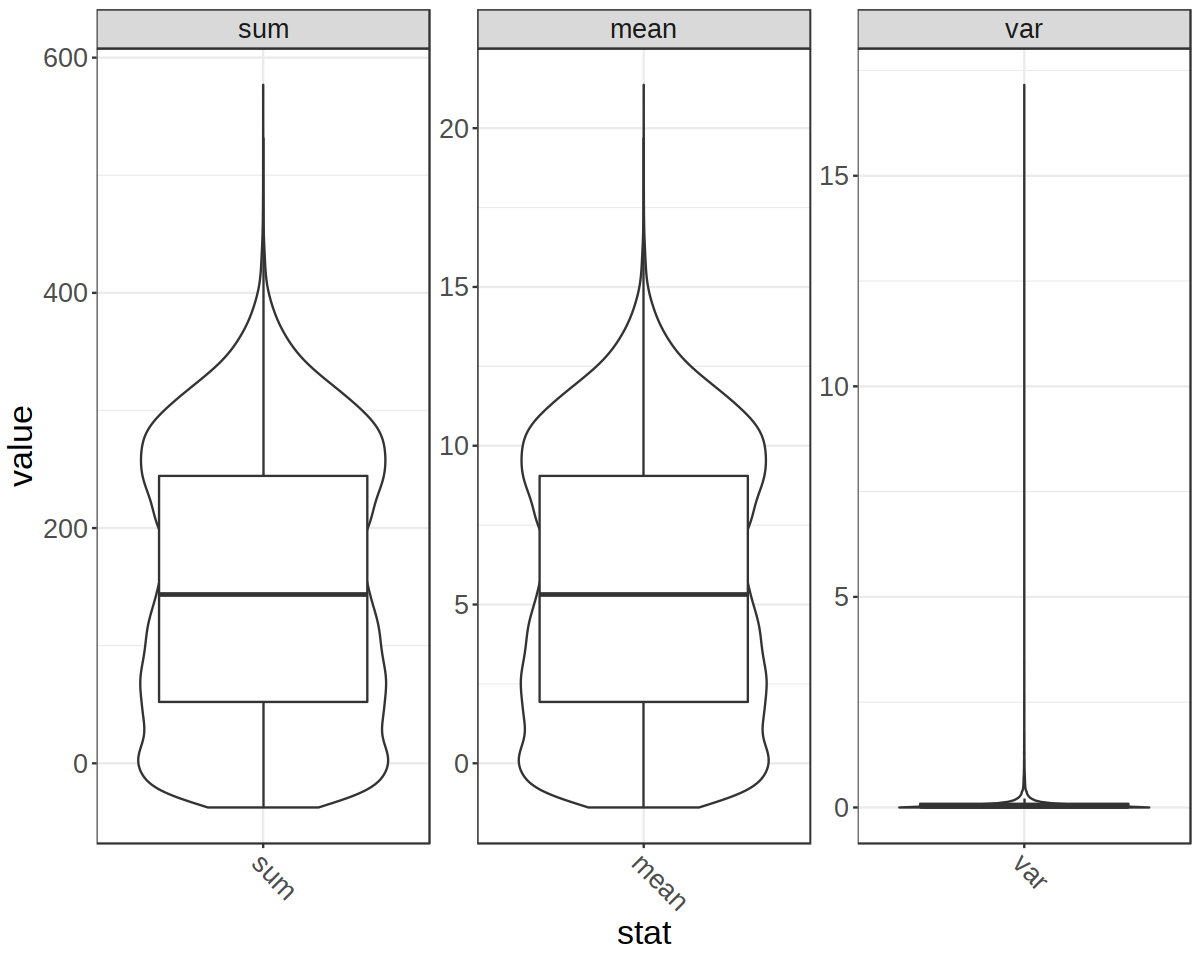

In [43]:
   ggplot(genes.long, aes(stat,value)) + 
geom_violin() +         
geom_boxplot(outlier.shape = NA) + 
  #      geom_point() + 
        facet_wrap(~stat, scales='free') +
        theme_bw() + 
        theme(text=element_text(size=20), 
                   axis.text.x=element_text(angle=-45, hjust=0, vjust=1))

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

Warning message:
“Removed 1020 rows containing non-finite values (stat_bin).”
Warning message:
“Removed 2 rows containing missing values (geom_bar).”


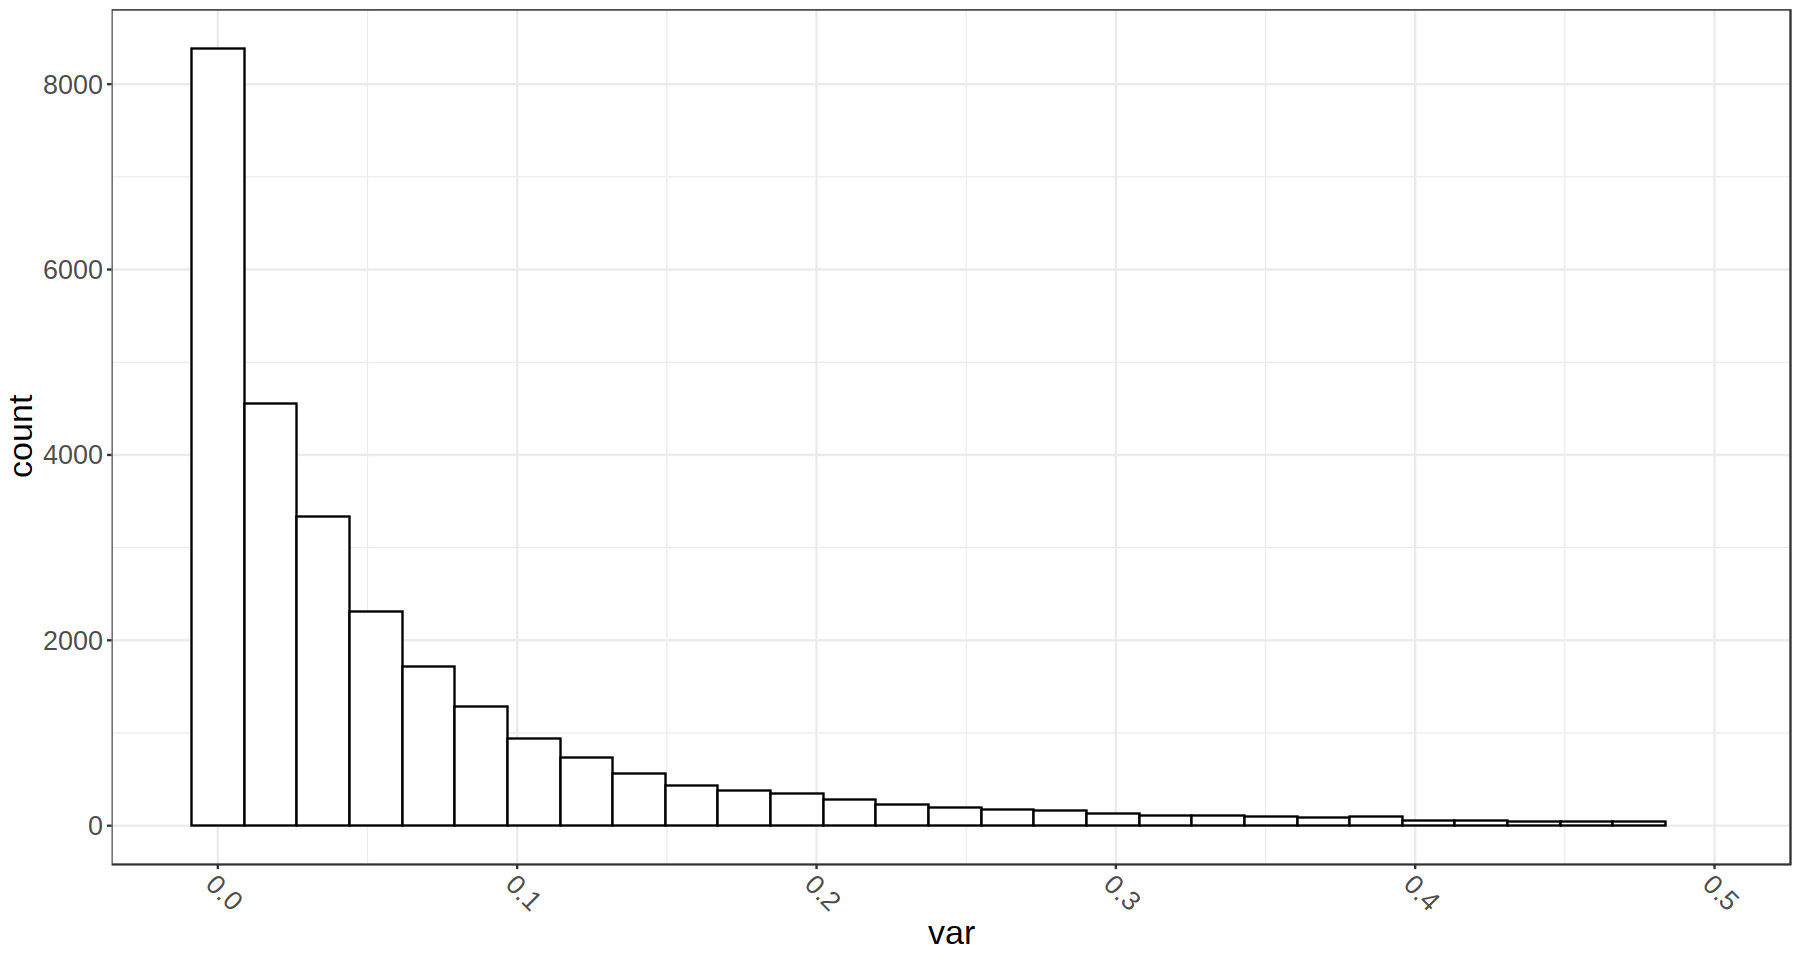

In [104]:
ggplot(genes, aes(var)) + 
    geom_histogram(col='black', fill='white') + 
    xlim(-0.01,0.5) + 
    theme_bw() + 
    theme(text=element_text(size=20), 
        axis.text.x=element_text(angle=-45, hjust=0, vjust=1))

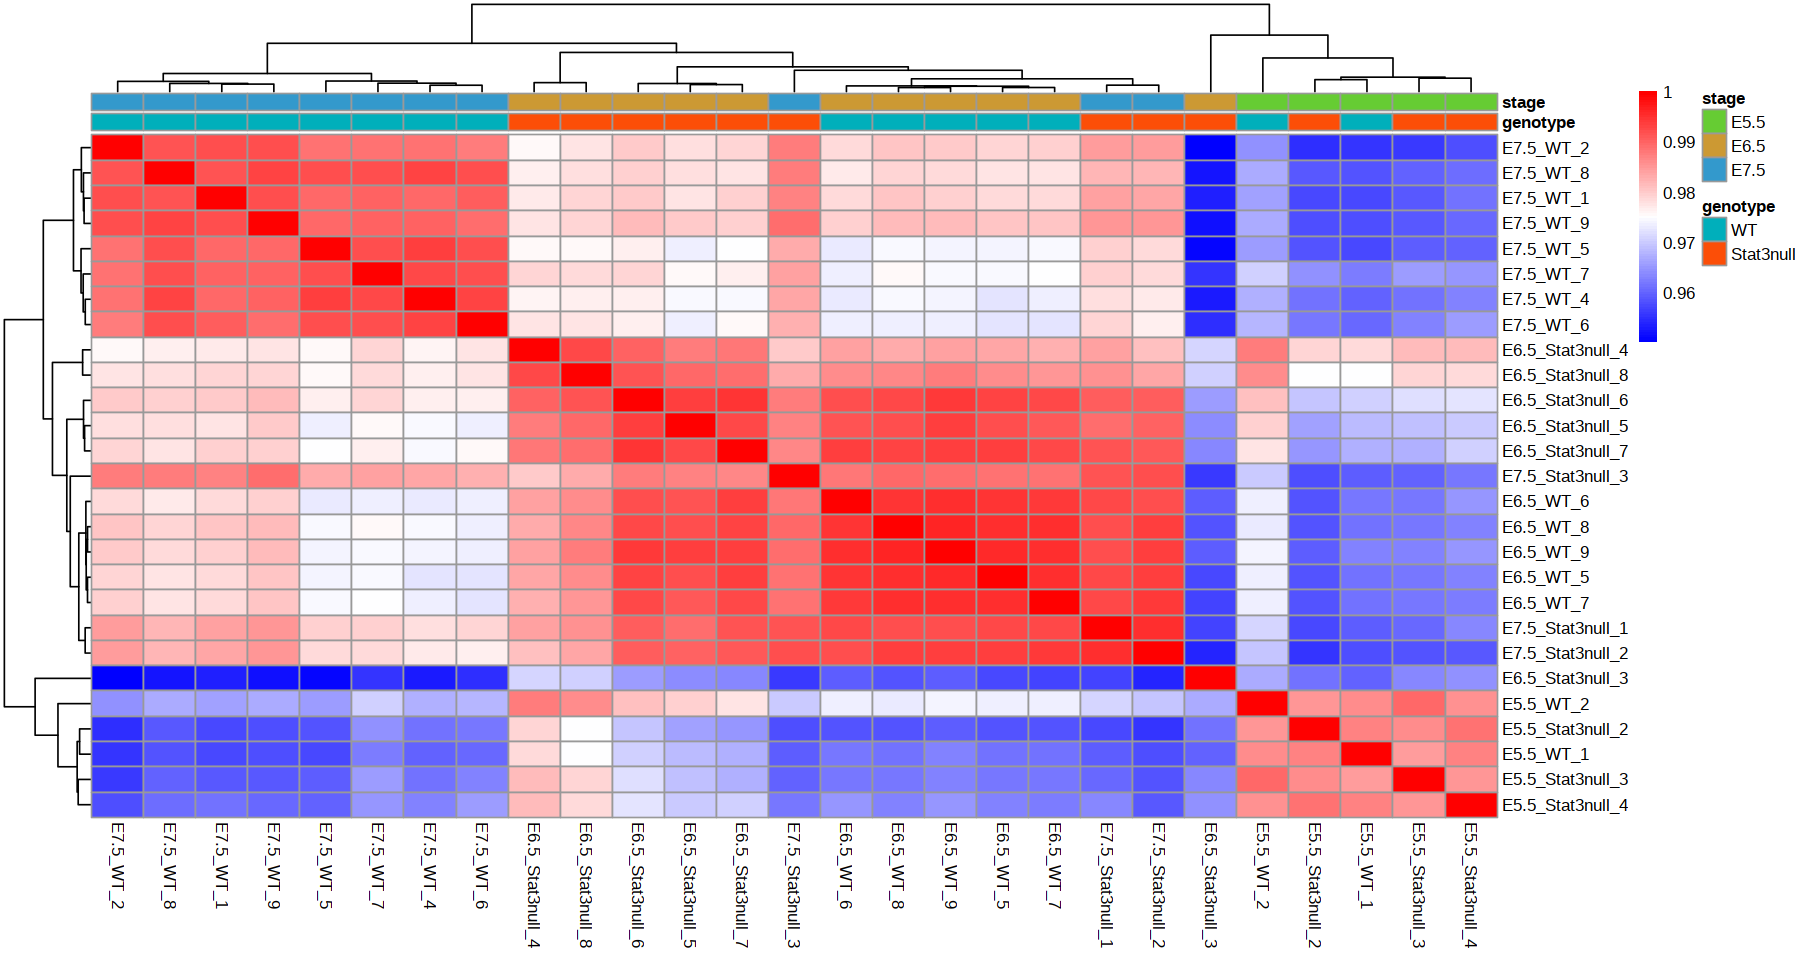

In [74]:
#Heatmap of the sample-to-sample distances
#removing genes that are not variable across any of the samples
var_genes = genes[var>0.02, gene]

counts_cor <- cor(counts[var_genes,])
colors <- colorRampPalette(c("blue","white","red"))(99)
annocolors <- list(
  genotype = c("WT"="#00afbb", "Stat3null"="#fc4e07"),
  stage = c("E5.5"="#66cc33", "E6.5"="#cc9933", "E7.5"="#3399cc")
)
colData$genotype <- factor(colData$genotype, levels = c("WT", "Stat3null"))

options(repr.plot.width=15, repr.plot.height=8) 
pheatmap(counts_cor,
         annotation_col = colData[,c('genotype', 'stage')],
         annotation_colors = annocolors,
         col=colors)

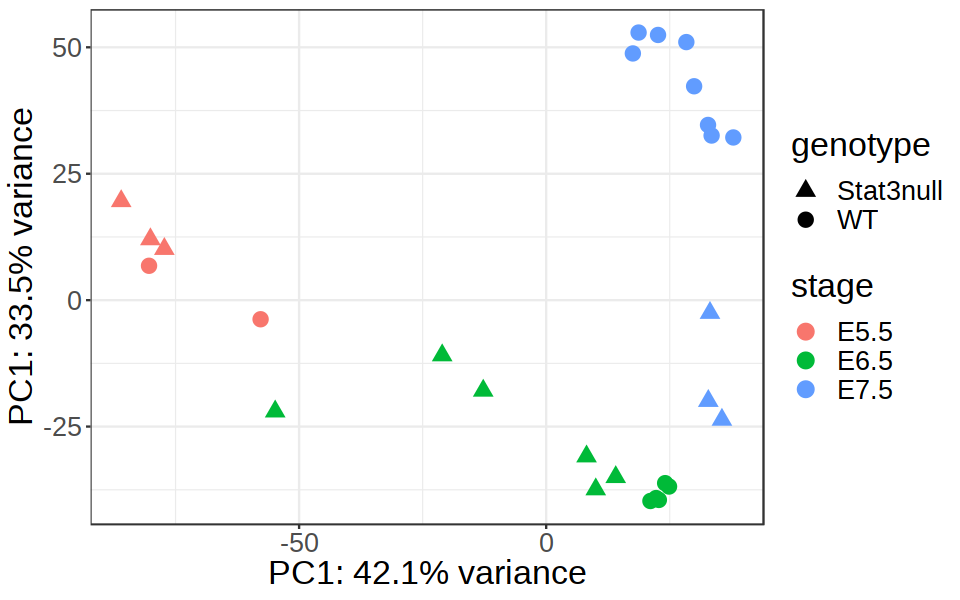

In [128]:
# Select variable genes
var_genes = genes[order(-var), gene] %>% head(5000)

# PCA 
pca = prcomp(t(as.matrix(counts[var_genes,])), scale=TRUE) # Does scale need to be TRUE?
meta_pca = cbind(meta_sample, pca$x)


options(repr.plot.width=8, repr.plot.height=5) 

# Plot
ggplot(meta_pca, aes(PC1, PC2, col=stage, shape=genotype)) + 
    scale_shape_manual(values=c('Stat3null'=17, 'WT'=16))+
    geom_point(size=4) +
    theme_bw() + 
    labs(x = paste0('PC1: ', round(pca$sdev[1],1), '% variance'),
         y =  paste0('PC1: ', round(pca$sdev[2],1), '% variance')) + 
    theme(text=element_text(size=20, color='black'))

In [112]:
summary(names(counts['Socs3', ]) == rownames(colE567))

   Mode    TRUE 
logical      27 

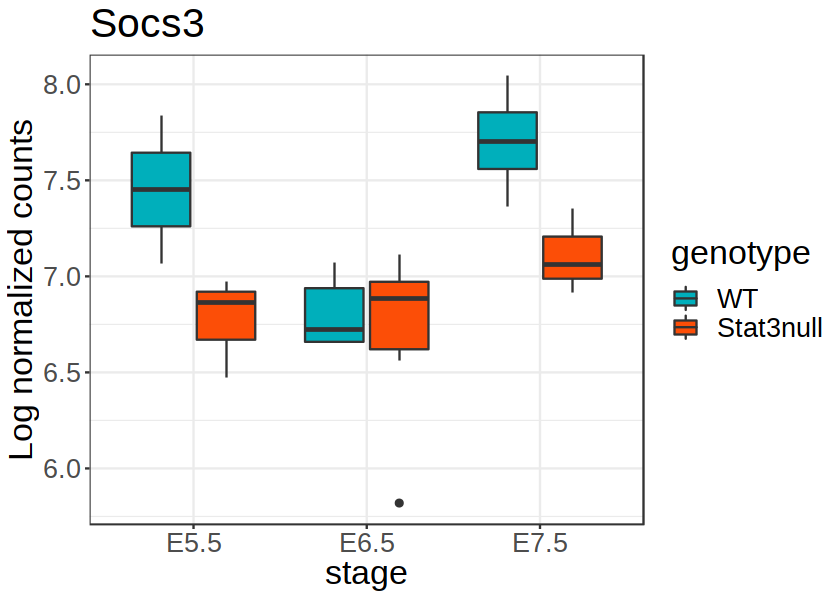

In [126]:
gene = 'Socs3'
tmp = cbind(colE567, data.frame(counts = counts[gene, ]))

options(repr.plot.width=7, repr.plot.height=5) 

ggplot(tmp, aes(stage, counts, fill=genotype)) +
    geom_boxplot() +
    scale_fill_manual(values = c("WT"="#00afbb", "Stat3null"="#fc4e07")) + 
    ggtitle(gene) + 
    ylab('Log normalized counts') + 
    theme_bw() + 
    theme(text=element_text(size=20, color='black'))

# with all samples

In [6]:
countData <- as.matrix(read.csv('gene_count_matrix_epiblast.csv', row.names = 'gene_id'))
rownames(countData) = rownames(countData) %>% strsplit('[|]') %>% map(2) # change rownames

colData <- read.csv('phenodata_epi2.csv', row.names = 1)
colData$genotype = gsub("-/-", "null", colData$genotype)
colData$group = paste0(colData$genotype, '_',colData$stage)


In [7]:
#E5.5, E6.5, E7.5
##Remove ex5.5 results
#select E7.5 data
colE567 <- colData[colData$stage!="ex5.5",]
#remove E7.5_WT_3
#colE567 <- colE567[!rownames(colE567) %in% c("E5.5_Stat3null_1", "E6.5_Stat3null_1", "E6.5_Stat3null_2", "E6.5_WT_1", "E6.5_WT_2", "E6.5_WT_3", "E6.5_WT_4", "E7.5_WT_3"), ]
colE567$genotype <- factor(colE567$genotype, levels = c("WT", "Stat3null"))
countDataE567 <- countData[, rownames(colE567)]
rownames(countDataE567) = make.names(rownames(countDataE567), unique=TRUE)
head(countDataE567)

,E5.5_Stat3null_1,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_1,E6.5_Stat3null_2,E6.5_Stat3null_3,E6.5_Stat3null_4,⋯,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_3,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
Xkr4,22,5,11,6,4,48,64,203,0,96,⋯,235,232,134,152,170,315,138,178,166,180
Gm18956,0,4,0,0,0,0,0,0,0,0,⋯,2,3,0,9,0,0,4,5,0,0
Gm37686,0,0,0,0,0,0,0,0,0,4,⋯,0,27,4,7,3,10,11,0,0,3
Gm1992,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Gm37329,0,5,11,20,0,0,0,0,0,0,⋯,10,9,13,19,9,0,23,8,18,0
Gm38148,0,19,23,11,0,7,79,0,0,33,⋯,6,50,47,88,25,43,8,36,63,91


In [8]:
##Check all sample IDs in colData are also in CountData and match their orders (phenodata.csvとサンプルが噛み合うか確認)
all(rownames(colE567) %in% colnames(countDataE567))
countDataE567 <- countDataE567[, rownames(colE567)]
all(rownames(colE567) == colnames(countDataE567))

[1] TRUE

[1] TRUE

In [9]:
##Create a DESeqDataSet from count matrix and labels (DESeqDataSetを作成）

ddsFullE567 <-DESeqDataSetFromMatrix(countData = countDataE567, colData = colE567, design = ~ stage + genotype + genotype:stage)  # group
ddsFullE567 <- ddsFullE567[rowSums(counts(ddsFullE567)) > 10, ]
ddsFullE567$genotype <- factor(ddsFullE567$genotype, levels = c("WT","Stat3null"))
ddsFullE567$stage <- factor(ddsFullE567$stage, levels = c("E5.5","E6.5", "E7.5")) # does DESeq just not work with 3 values?


# Normalisation
ddsFullE567 <- estimateSizeFactors(ddsFullE567)
normalized_counts <- counts(ddsFullE567, normalized=TRUE)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


In [10]:
#normalization
rld_E567 <- rlog(ddsFullE567, blind = TRUE)
rld_E567$genotype <- factor(rld_E567$genotype, levels = c("WT", "Stat3null"))

rlog() may take a few minutes with 30 or more samples,
vst() is a much faster transformation



In [11]:
counts = assay(rld_E567)

In [12]:
head(colData)

,stage,genotype,cluster,group
,<chr>,<chr>,<int>,<chr>
E5.5_Stat3null_1,E5.5,Stat3null,1,Stat3null_E5.5
E5.5_Stat3null_2,E5.5,Stat3null,1,Stat3null_E5.5
E5.5_Stat3null_3,E5.5,Stat3null,1,Stat3null_E5.5
E5.5_Stat3null_4,E5.5,Stat3null,1,Stat3null_E5.5
E5.5_WT_1,E5.5,WT,1,WT_E5.5
E5.5_WT_2,E5.5,WT,1,WT_E5.5


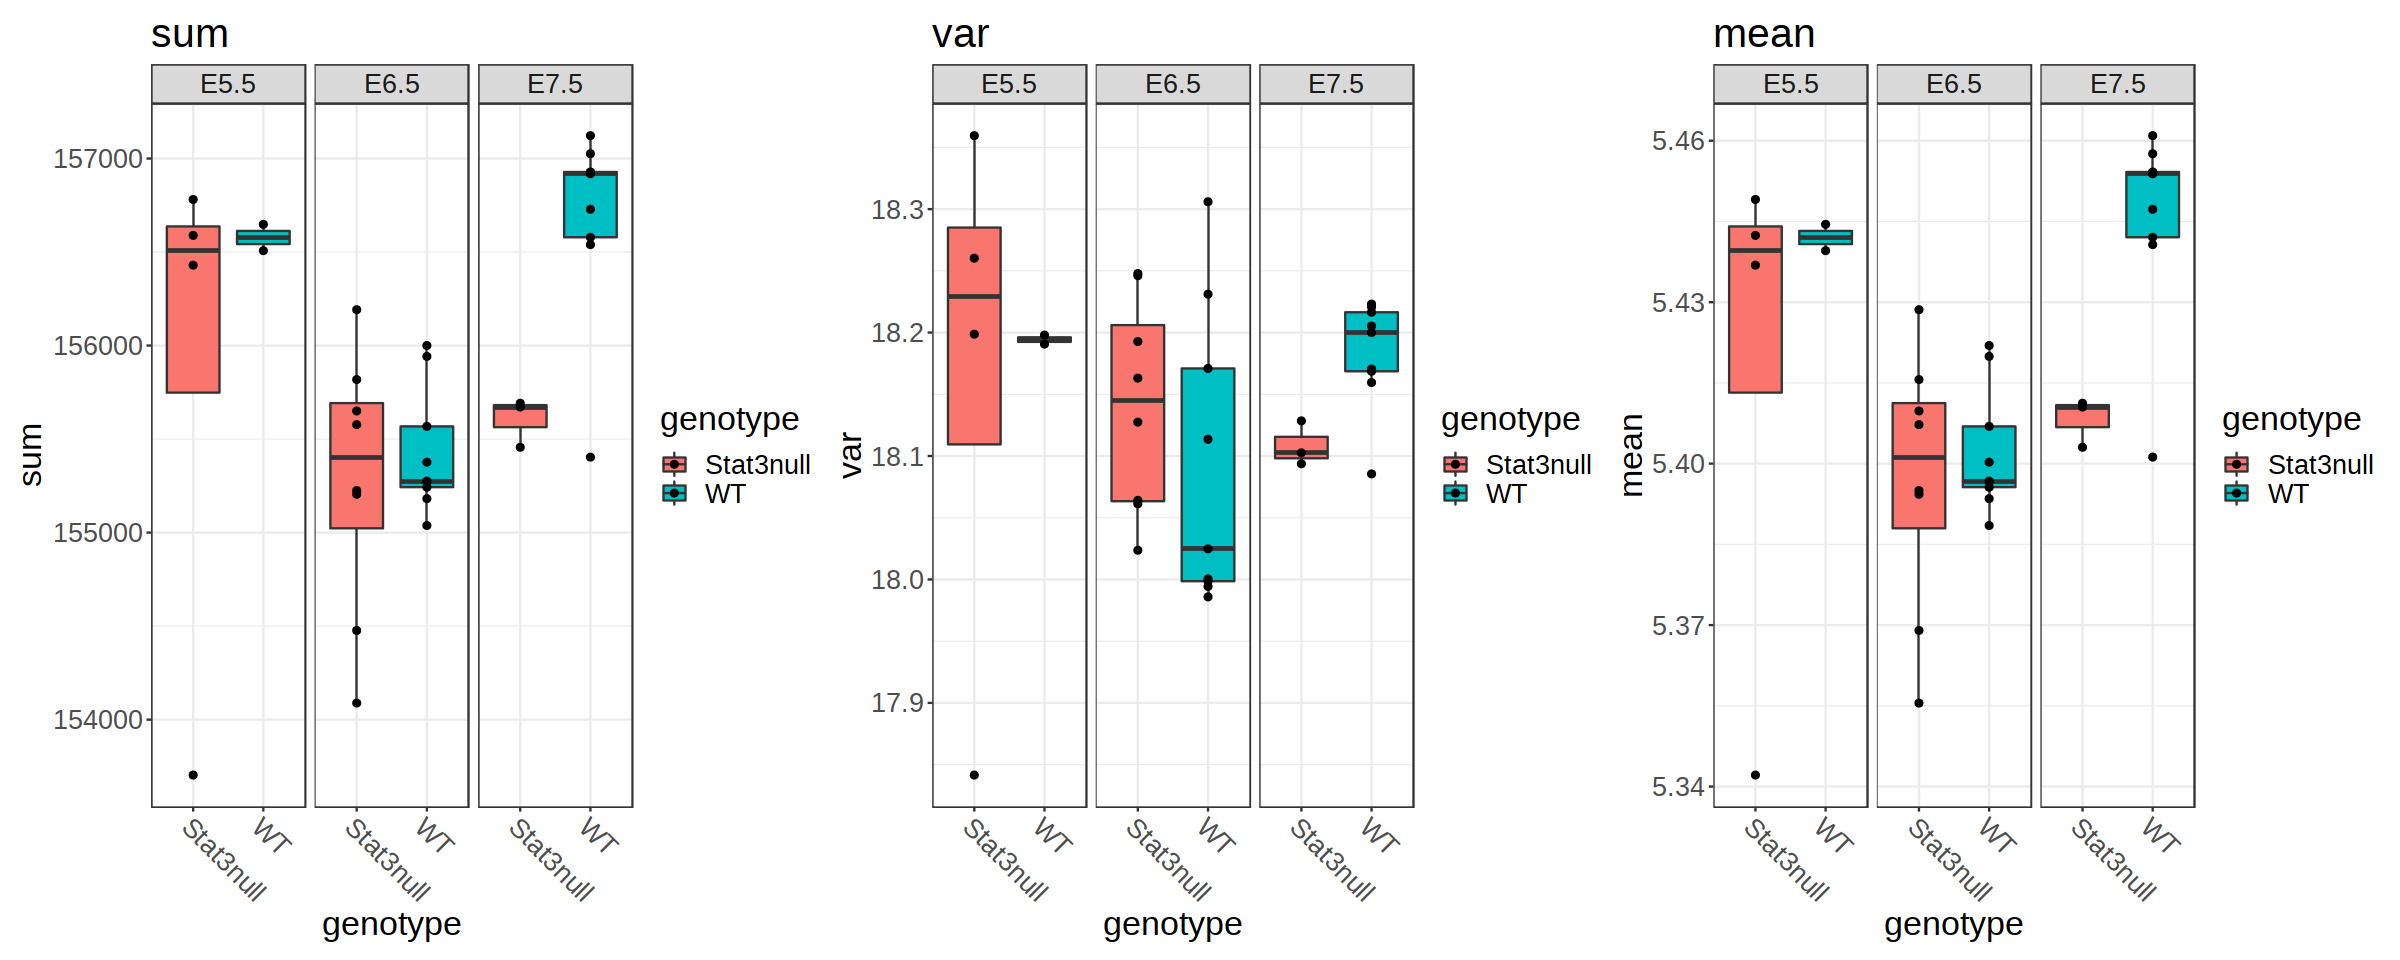

In [13]:
# sample statistics
sample = data.table(sample=colnames(counts), 
                   sum = colSums(counts), 
                   mean = colMeans(counts), 
                   var = colVars(counts))
meta_sample = merge(colData, sample, by.x=0, by.y='sample')

plot_stat = function(x){
    ggplot(meta_sample, aes_string('genotype', x, fill='genotype')) + 
        geom_boxplot(outlier.shape = NA) + 
        geom_point() + 
        viridis::scale_color_viridis() + 
        facet_wrap(~stage) + 
        ggtitle(x) +
        theme_bw() + 
        theme(text=element_text(size=20), 
                   axis.text.x=element_text(angle=-45, hjust=0, vjust=1))
    }
options(repr.plot.width=20, repr.plot.height=8)
plot_stat('sum') + plot_stat('var') + plot_stat('mean')
options(repr.plot.width=10, repr.plot.height=8)

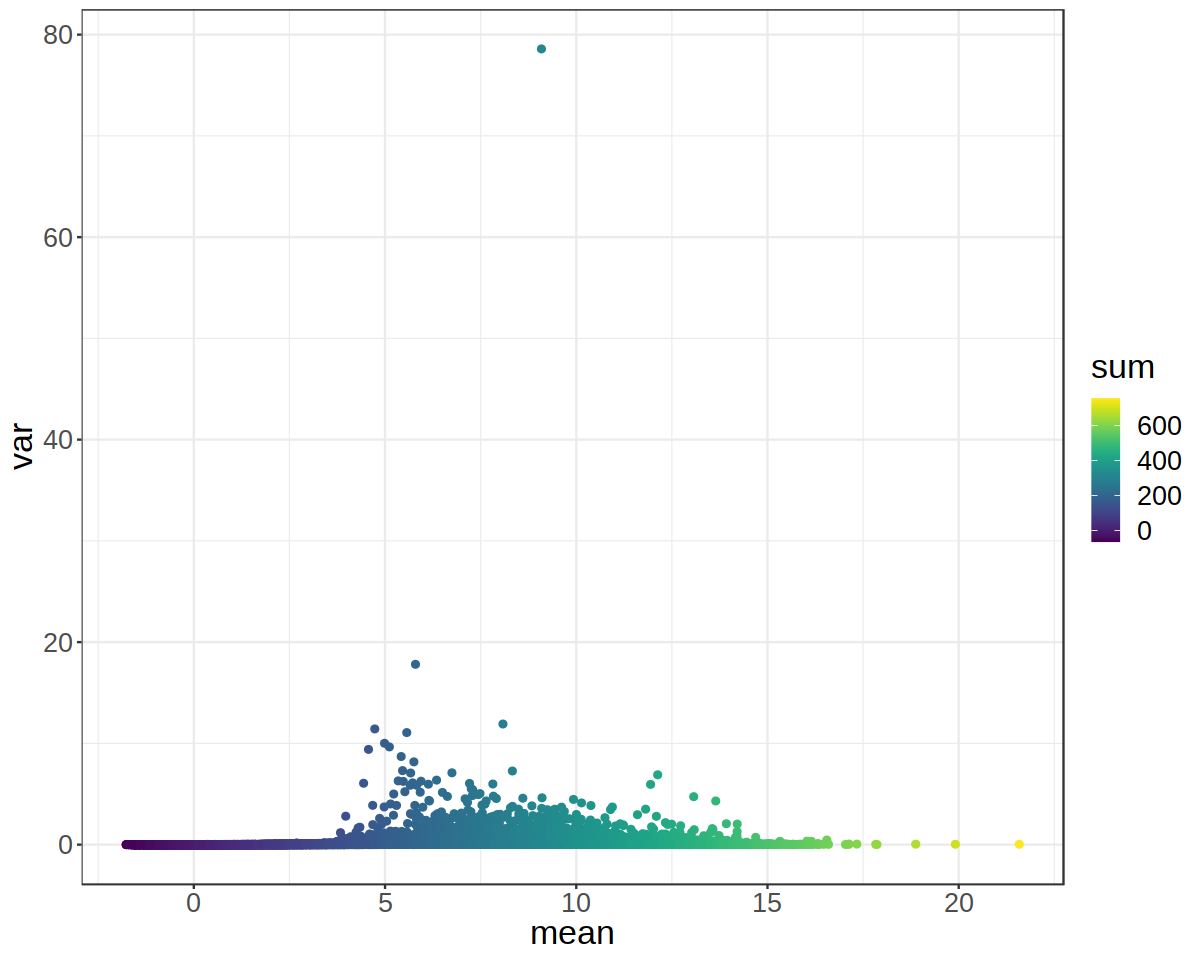

In [14]:
# Gene statistics
genes = data.table(gene=rownames(counts), 
                   sum = rowSums(counts), 
                   mean = rowMeans(counts), 
                   var = rowVars(counts))

ggplot(genes, aes(mean, var, col=sum)) + 
    geom_point() + 
    viridis::scale_color_viridis() + 
    theme_bw() + theme(text=element_text(size=20))

In [15]:
head(genes)

gene,sum,mean,var
<chr>,<dbl>,<dbl>,<dbl>
Xkr4,231.135796,6.6038799,0.269979119
Gm18956,-6.112773,-0.1746507,0.000413513
Gm37686,80.443991,2.2983997,0.004461984
Gm37329,118.599845,3.3885670,0.013179706
Gm38148,185.521000,5.3006000,0.110174603
Gm37180,163.737880,4.6782251,0.049120421


In [16]:
genes.long = genes %>% melt(id.vars = 'gene', variable.name = "stat", value.name = 'value')

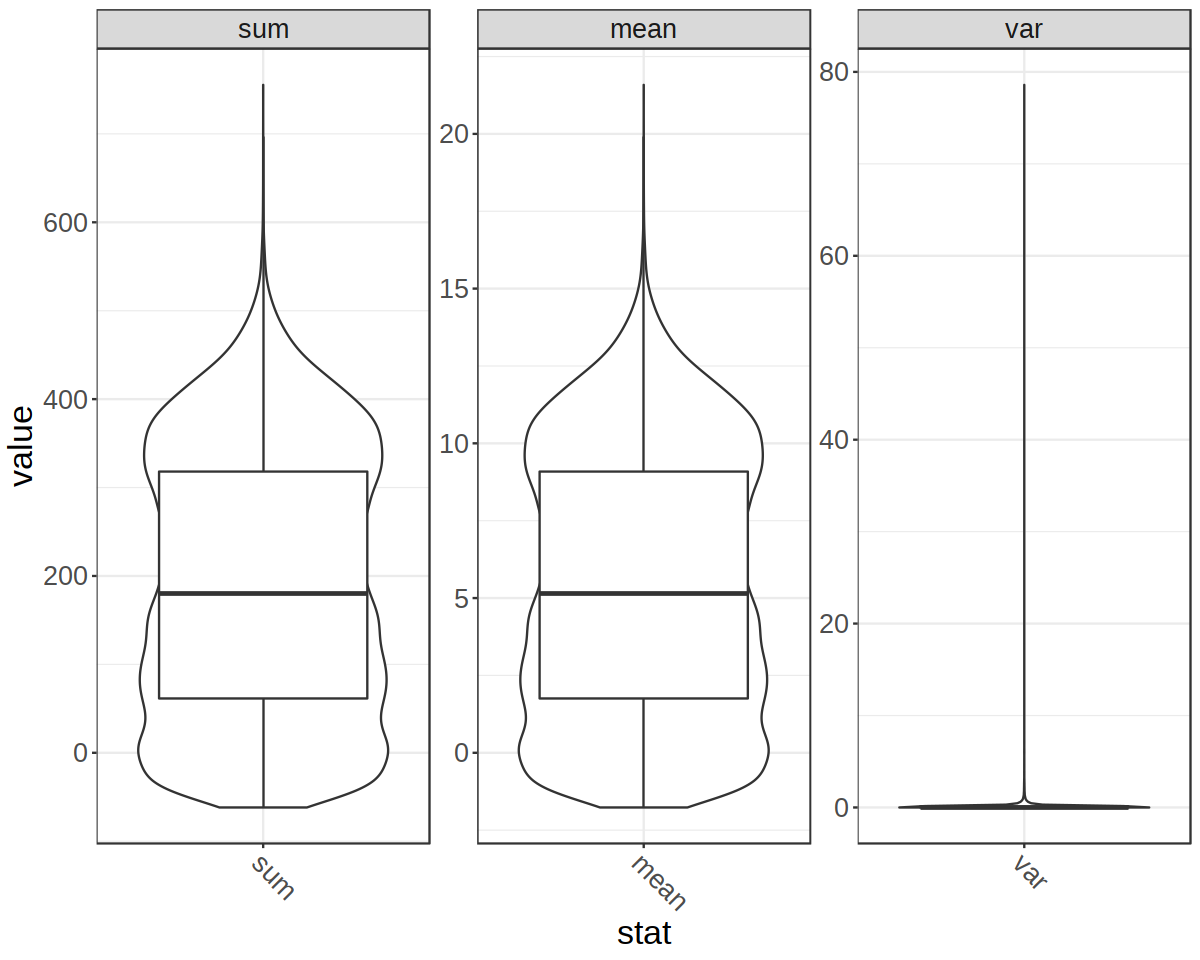

In [17]:
   ggplot(genes.long, aes(stat,value)) + 
geom_violin() +         
geom_boxplot(outlier.shape = NA) + 
  #      geom_point() + 
        facet_wrap(~stat, scales='free') +
        theme_bw() + 
        theme(text=element_text(size=20), 
                   axis.text.x=element_text(angle=-45, hjust=0, vjust=1))

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

Warning message:
“Removed 1347 rows containing non-finite values (stat_bin).”
Warning message:
“Removed 2 rows containing missing values (geom_bar).”


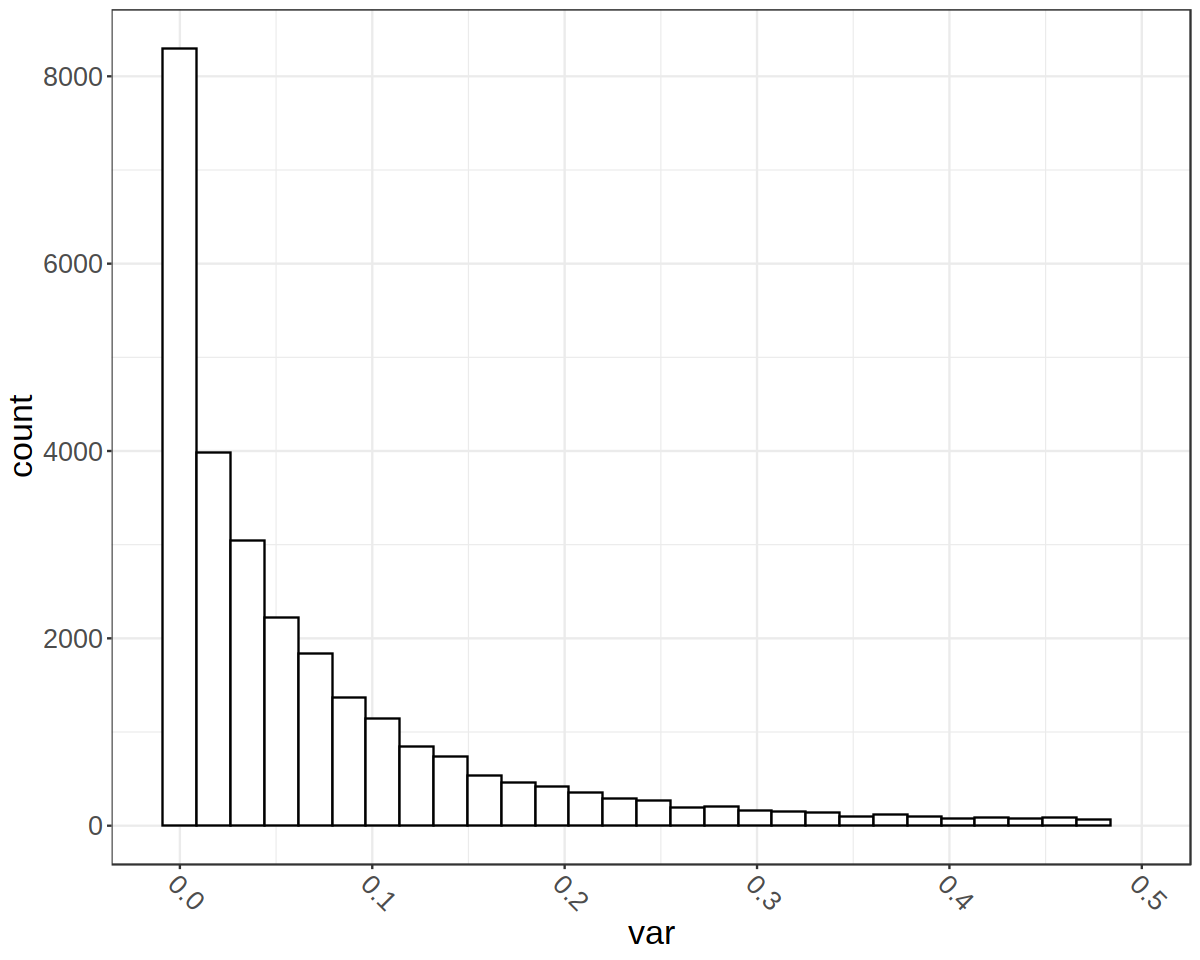

In [18]:
ggplot(genes, aes(var)) + 
    geom_histogram(col='black', fill='white') + 
    xlim(-0.01,0.5) + 
    theme_bw() + 
    theme(text=element_text(size=20), 
        axis.text.x=element_text(angle=-45, hjust=0, vjust=1))

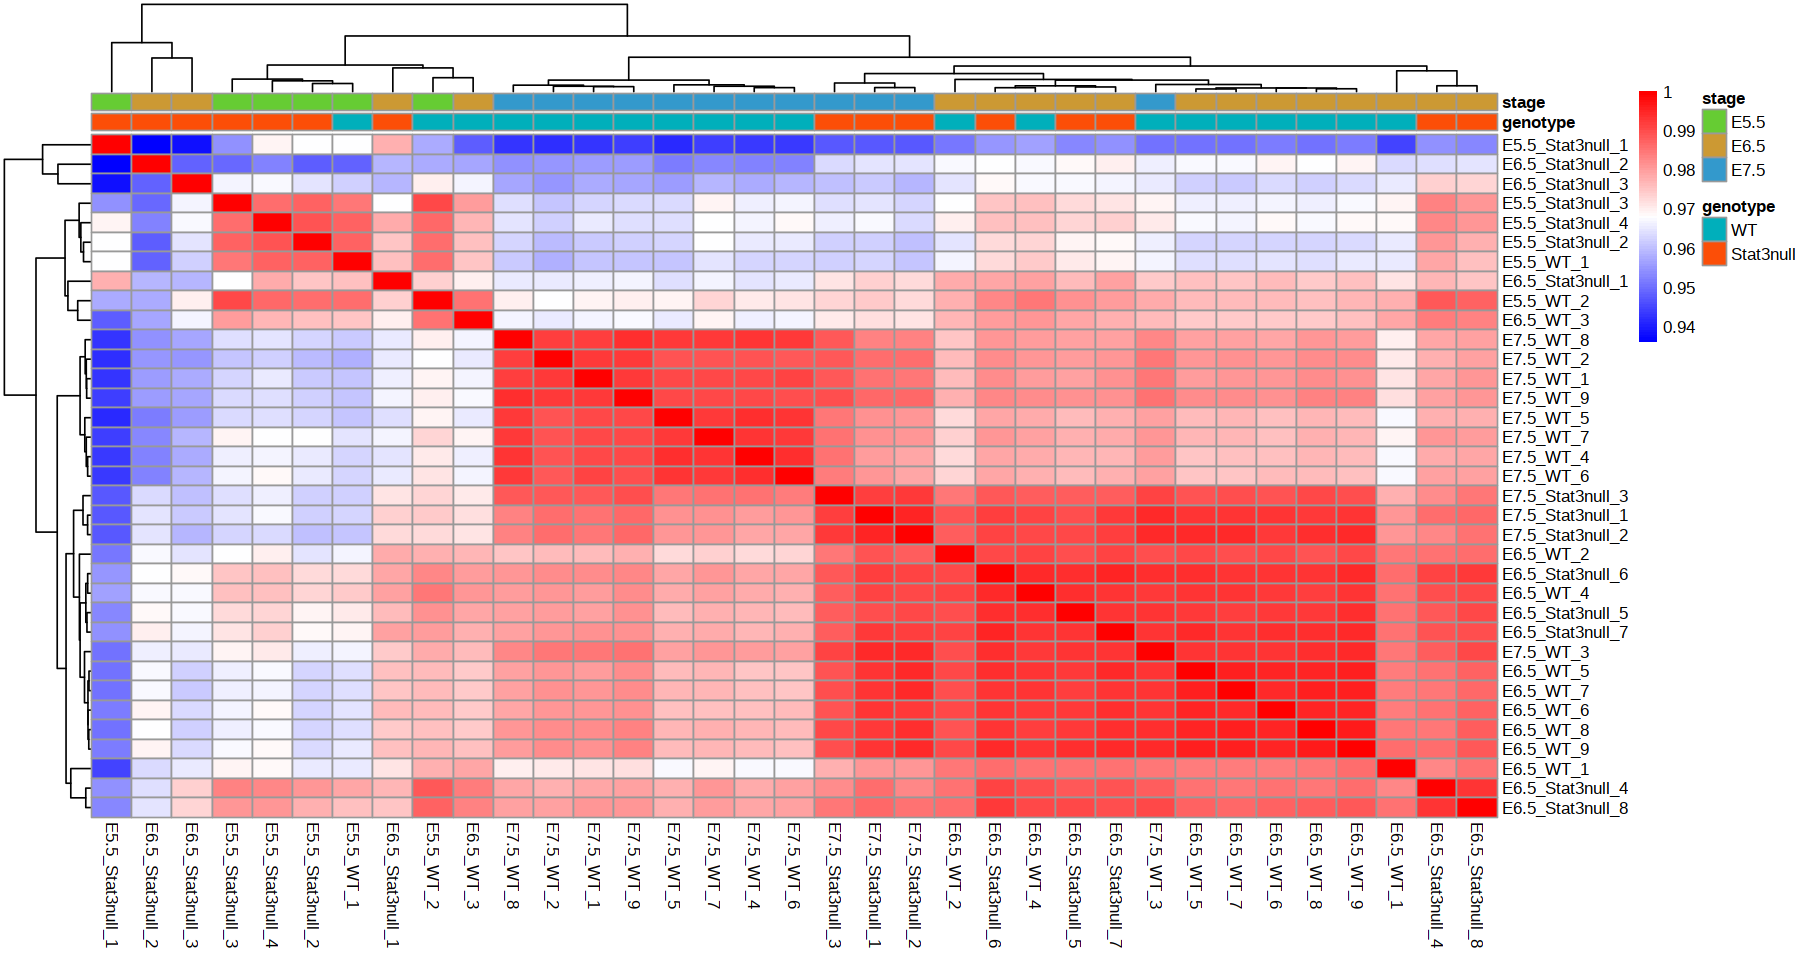

In [19]:
#Heatmap of the sample-to-sample distances
#removing genes that are not variable across any of the samples
var_genes = genes[var>0.02, gene]

counts_cor <- cor(counts[var_genes,])
colors <- colorRampPalette(c("blue","white","red"))(99)
annocolors <- list(
  genotype = c("WT"="#00afbb", "Stat3null"="#fc4e07"),
  stage = c("E5.5"="#66cc33", "E6.5"="#cc9933", "E7.5"="#3399cc")
)
colData$genotype <- factor(colData$genotype, levels = c("WT", "Stat3null"))

options(repr.plot.width=15, repr.plot.height=8) 
pheatmap(counts_cor,
         annotation_col = colData[,c('genotype', 'stage')],
         annotation_colors = annocolors,
         col=colors)

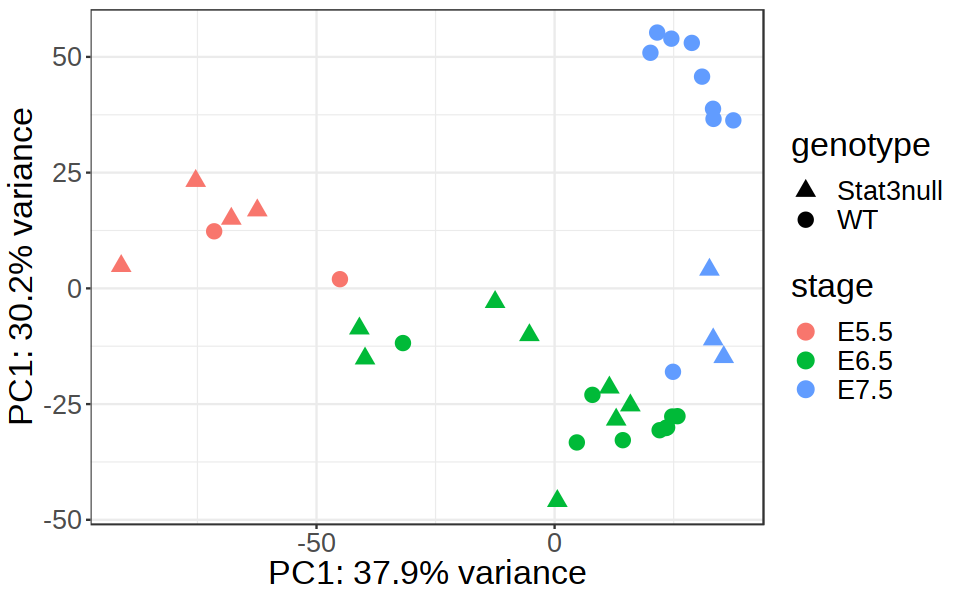

In [20]:
# Select variable genes
var_genes = genes[order(-var), gene] %>% head(5000)

# PCA 
pca = prcomp(t(as.matrix(counts[var_genes,])), scale=TRUE) # Does scale need to be TRUE?
meta_pca = cbind(meta_sample, pca$x)


options(repr.plot.width=8, repr.plot.height=5) 

# Plot
ggplot(meta_pca, aes(PC1, PC2, col=stage, shape=genotype)) + 
    scale_shape_manual(values=c('Stat3null'=17, 'WT'=16))+
    geom_point(size=4) +
    theme_bw() + 
    labs(x = paste0('PC1: ', round(pca$sdev[1],1), '% variance'),
         y =  paste0('PC1: ', round(pca$sdev[2],1), '% variance')) + 
    theme(text=element_text(size=20, color='black'))